# 01 — Exploratory Data Analysis

Fraud Detection project — IEEE-CIS dataset.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.data_loading import load_transaction_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = load_transaction_data(raw_dir="../data/raw")
df.shape

(590540, 434)

## 1. Schema & shape validation

Confirm the merge behaved as expected before doing anything else — catching a
broken merge here beats discovering it three notebooks later.

In [2]:
assert df["TransactionID"].is_unique, "TransactionID should be unique per row"
assert len(df) == 590_540, "Row count should match train_transaction.csv exactly (left join)"

print(f"Shape: {df.shape}")
print(f"\nDtype counts:\n{df.dtypes.value_counts()}")

Shape: (590540, 434)

Dtype counts:
float64    399
object      31
int64        4
Name: count, dtype: int64


## 2. Target variable — class imbalance

The whole modeling strategy hinges on this number.

Fraud rate: 3.50%
A model that always predicts 'not fraud' scores 96.50% accuracy — accuracy is useless here.


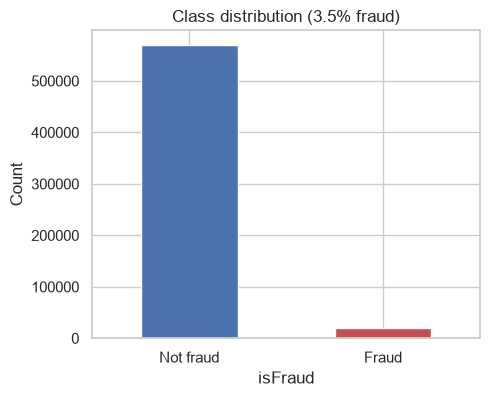

In [3]:
fraud_rate = df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.2%}")
print(f"A model that always predicts 'not fraud' scores {1 - fraud_rate:.2%} accuracy — accuracy is useless here.")

fig, ax = plt.subplots(figsize=(5, 4))
df["isFraud"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Not fraud", "Fraud"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Class distribution ({fraud_rate:.1%} fraud)")
plt.show()

## 3. Missing data

**Important:** the `id_*` and `Device*` columns are missing ~76% of the time
*by construction* — only 24.4% of transactions have any identity data at all,
so a null there doesn't mean "bad data," it means "no identity record exists
for this transaction." The `D*`/`V*` columns with high missingness are a
different story — genuine sparsity in the engineered features that we'll need
a real strategy for in `03_feature_engineering.ipynb` (e.g. imputation,
missingness indicators, or dropping columns above some threshold).

Columns with >0% missing: 414 / 434


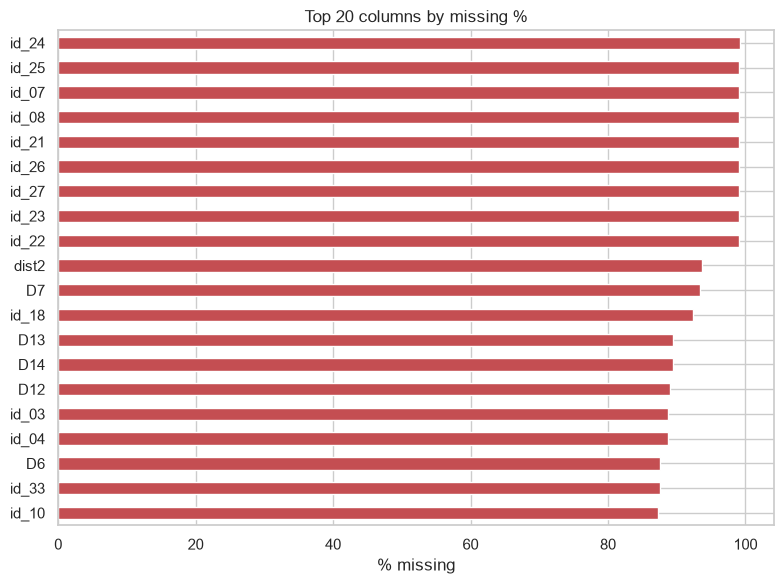

In [4]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
print(f"Columns with >0% missing: {(missing_pct > 0).sum()} / {len(missing_pct)}")

fig, ax = plt.subplots(figsize=(8, 6))
missing_pct.head(20).plot(kind="barh", ax=ax, color="#C44E52")
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("Top 20 columns by missing %")
plt.tight_layout()
plt.show()

## 4. Numeric feature distributions

`TransactionAmt` is heavily right-skewed (a few very large transactions), so
we compare raw vs. log scale. `TransactionDT` isn't a real timestamp — it's a
time delta in seconds from an arbitrary reference point — so we convert it to
a day count to see the ~6-month span the dataset covers.

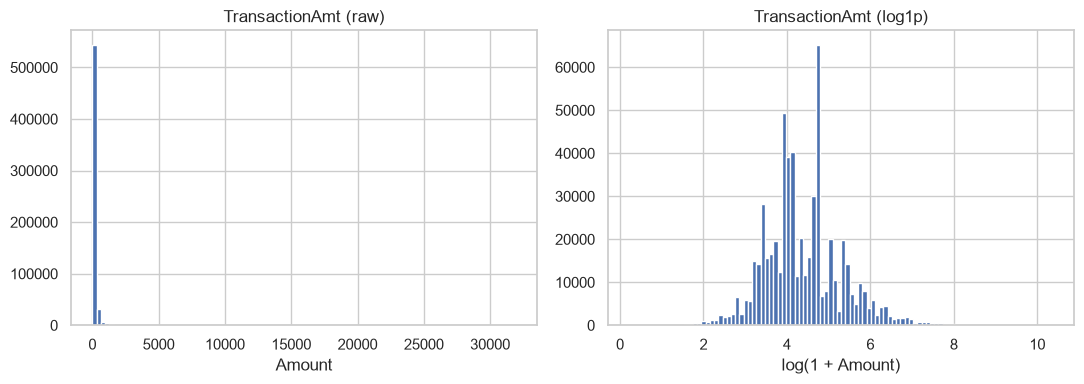

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["TransactionAmt"], bins=100, color="#4C72B0")
axes[0].set_title("TransactionAmt (raw)")
axes[0].set_xlabel("Amount")

axes[1].hist(np.log1p(df["TransactionAmt"]), bins=100, color="#4C72B0")
axes[1].set_title("TransactionAmt (log1p)")
axes[1].set_xlabel("log(1 + Amount)")

plt.tight_layout()
plt.show()

print(df["TransactionAmt"].describe())

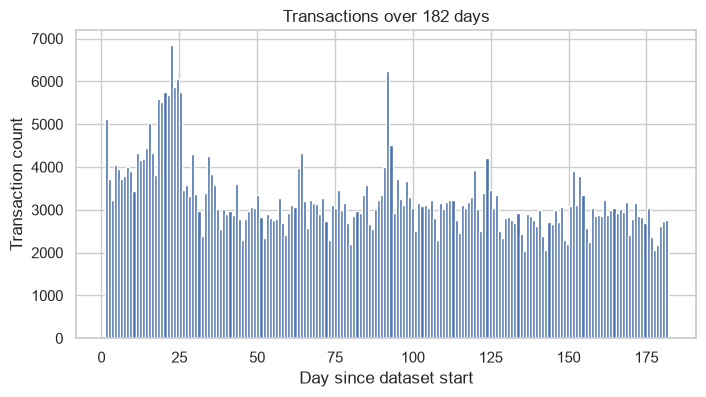

In [6]:
df["TransactionDay"] = df["TransactionDT"] // (24 * 60 * 60)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["TransactionDay"], bins=182, color="#4C72B0")
ax.set_xlabel("Day since dataset start")
ax.set_ylabel("Transaction count")
ax.set_title(f"Transactions over {df['TransactionDay'].max():.0f} days")
plt.show()

## 5. Categorical features — fraud rate by category

Raw value counts only tell us how common a category is, not whether it's
predictive. Fraud rate *within* each category is the more useful view here.

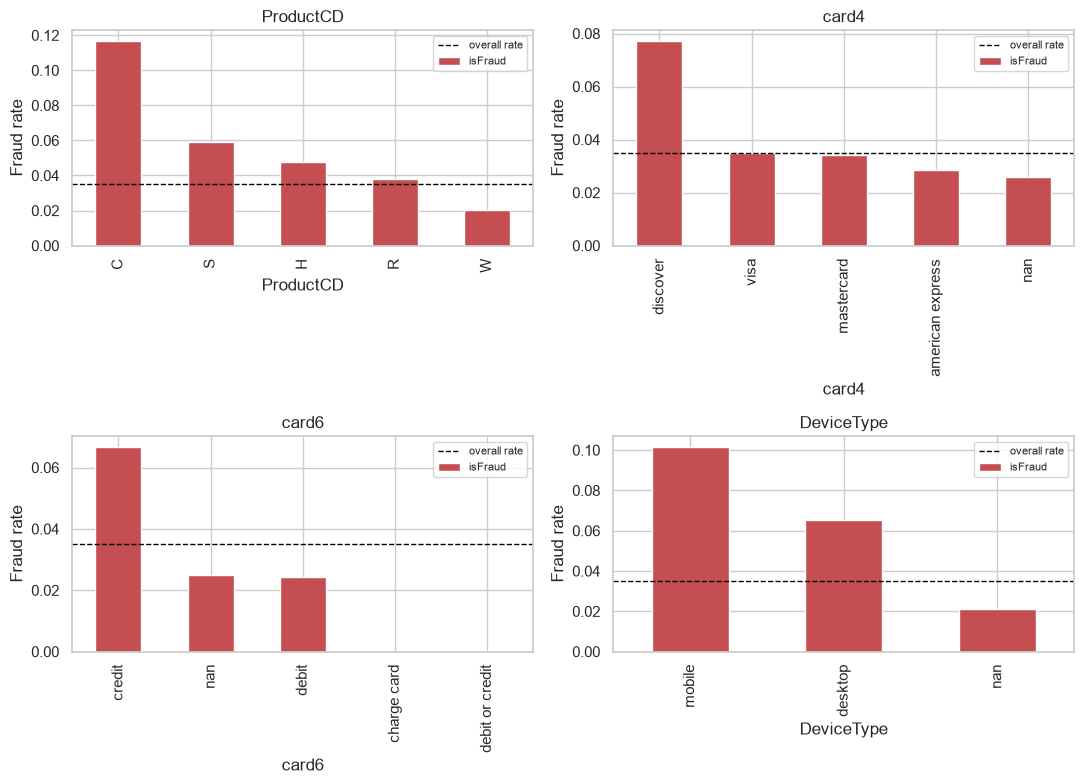

In [7]:
categorical_cols = ["ProductCD", "card4", "card6", "DeviceType"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, ax in zip(categorical_cols, axes.flat):
    fraud_by_cat = df.groupby(col, dropna=False)["isFraud"].mean().sort_values(ascending=False)
    fraud_by_cat.plot(kind="bar", ax=ax, color="#C44E52")
    ax.axhline(fraud_rate, color="black", linestyle="--", linewidth=1, label="overall rate")
    ax.set_title(col)
    ax.set_ylabel("Fraud rate")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Fraud rate over time

Checks whether fraud is roughly stationary across the 6-month window or
drifts — directly informs whether a time-based train/validation split (train
on earlier days, validate on later days) is just good practice or a hard
requirement for this dataset.

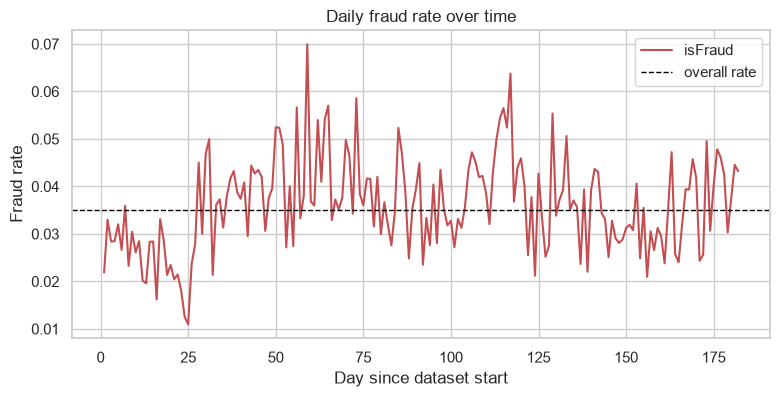

In [8]:
fraud_rate_by_day = df.groupby("TransactionDay")["isFraud"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
fraud_rate_by_day.plot(ax=ax, color="#C44E52")
ax.axhline(fraud_rate, color="black", linestyle="--", linewidth=1, label="overall rate")
ax.set_xlabel("Day since dataset start")
ax.set_ylabel("Fraud rate")
ax.set_title("Daily fraud rate over time")
ax.legend()
plt.show()

## 7. Summary of findings

These are the takeaways that will drive the next notebooks:

- **Severe class imbalance (3.5% fraud)** — plain accuracy is meaningless;
  `04_imbalanced_learning.ipynb` needs to cover class weights, SMOTE/
  undersampling, and threshold moving. Evaluation later must use PR-AUC /
  recall-precision, not accuracy.
- **Identity columns are ~76% null by design**, not a data quality issue —
  keep them, but the missingness itself might be a useful signal (e.g. a
  `has_identity_data` flag) rather than something to just impute away.
- **`D*`/`V*` columns have genuine high missingness (86-94%)** — needs a real
  strategy in `03_feature_engineering.ipynb`: imputation, missingness
  indicators, or dropping columns past some threshold.
- **`TransactionAmt` is right-skewed** — log-transform is a strong candidate
  feature for modeling.
- **Fraud rate is not perfectly stationary over the 6-month window** — any
  train/validation split must be **time-based** (train on earlier days,
  validate on later days), never a random split, to avoid leaking
  future-pattern information into training.
- **`ProductCD`, `card4`, `card6`, `DeviceType` show visibly different fraud
  rates by category** — real predictive signal worth encoding carefully in
  feature engineering.

Next: `02_statistical_analysis.ipynb` — hypothesis testing to statistically
confirm which features actually relate to fraud before we build on them.

## 8. Save merged data for reuse

Saving as Parquet (not CSV) so later notebooks don't each have to re-load and
re-merge the ~700MB of source CSVs from scratch — smaller on disk, preserves
dtypes, and much faster to read back in.

In [9]:
output_path = Path("../data/processed/train_merged.parquet")
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(output_path, index=False)
print(f"Saved {df.shape} to {output_path}")

Saved (590540, 435) to ../data/processed/train_merged.parquet
